# Part C2: Polynomial Fitting and Lasso Regularization

Roll No: `CS26S510`

---

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge, Lasso

np.random.seed(1)
n = 80
x = np.sort(np.random.uniform(-1, 1, n))
y_true = np.sin(2 * np.pi * x) + 0.5 * x**2
y = y_true + np.random.normal(0, 0.25, n)



## (a) Polynomial Fitting (p = 1, 3, 9, 15)

Build polynomial design matrix manually. Fit via normal equation. Plot fitted curves + report train/test RMSE table. Identify under/overfitting.

In [3]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=1)
print(x_train.shape, x_test.shape)

(56,) (24,)


In [4]:
def make_poly_design_matrix(x, p):
    """Build design matrix with columns [1, x, x^2, ..., x^p]."""
    n = len(x)
    A = np.zeros((n, p + 1))
    for j in range(p + 1):
        A[:, j] = x ** j
    return A

In [5]:
def normal_equation(A, y):
    AtA = A.T @ A
    Aty = A.T @ y
    theta_hat = np.linalg.solve(AtA, Aty)
    return theta_hat

def rmse(A, theta, y):
    residuals = y - A @ theta
    return np.sqrt(np.mean(residuals**2))

In [6]:
degrees = [1, 3, 9, 15]
results_c2a = {}

for p in degrees:
    A_train_poly = make_poly_design_matrix(x_train, p)
    A_test_poly = make_poly_design_matrix(x_test, p)
    
    theta_p = normal_equation(A_train_poly, y_train)
    
    train_rmse_p = rmse(A_train_poly, theta_p, y_train)
    test_rmse_p = rmse(A_test_poly, theta_p, y_test)
    
    results_c2a[p] = {"theta": theta_p, "train_rmse": train_rmse_p, "test_rmse": test_rmse_p}
    print(f"p={p}: train RMSE={train_rmse_p:.4f}, test RMSE={test_rmse_p:.4f}")

p=1: train RMSE=0.5729, test RMSE=0.9384
p=3: train RMSE=0.5202, test RMSE=0.8226
p=9: train RMSE=0.2037, test RMSE=0.2833
p=15: train RMSE=0.1787, test RMSE=0.3125


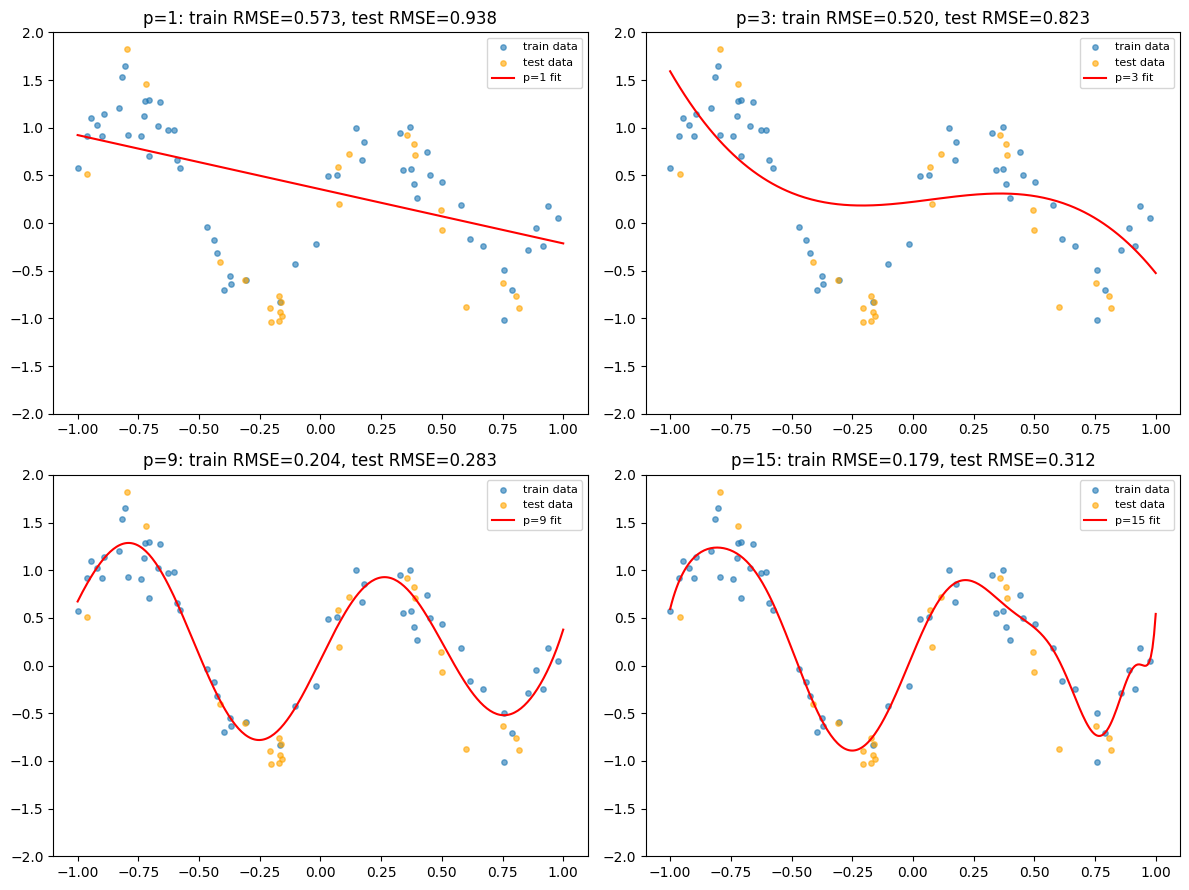

In [7]:
x_plot = np.linspace(-1, 1, 300)  # smooth grid for plotting the fitted curve

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
axes = axes.flatten()

for ax, p in zip(axes, degrees):
    theta_p = results_c2a[p]["theta"]
    A_plot_poly = make_poly_design_matrix(x_plot, p)
    y_plot_pred = A_plot_poly @ theta_p
    
    ax.scatter(x_train, y_train, s=15, alpha=0.6, label="train data")
    ax.scatter(x_test, y_test, s=15, alpha=0.6, color='orange', label="test data")
    ax.plot(x_plot, y_plot_pred, color='red', label=f"p={p} fit")
    ax.set_title(f"p={p}: train RMSE={results_c2a[p]['train_rmse']:.3f}, test RMSE={results_c2a[p]['test_rmse']:.3f}")
    ax.legend(fontsize=8)
    ax.set_ylim(-2, 2)

plt.tight_layout()
plt.show()

**Discussion:** I fit polynomials of degree p ∈ {1, 3, 9, 15} using the normal equation. p=1 and p=3 both show high train AND test RMSE, and their fitted curves visually fail to capture the oscillatory shape of the true function — this is underfitting, since the model doesn't have enough capacity regardless of the data. p=9 achieves the best test RMSE (0.283) and its fitted curve closely tracks the true sine-plus-quadratic trend through both train and test points. p=15 has the lowest train RMSE (0.179) but a worse test RMSE (0.312) than p=9 — visually, its curve is nearly identical to p=9's in the middle of the range but develops a sharp upward wiggle near the right boundary (x≈1), where it bends to fit a couple of noisy training points rather than the underlying trend. This is a textbook case of overfitting: the extra flexibility of a 16-parameter model lets it fit noise specific to the training set, which then hurts generalization to unseen test points.

## (b) Ridge vs Lasso across λ

Fit Ridge & Lasso (sklearn) for p=15 across given λ grid. Plot train/test RMSE vs λ (log-x). Report best λ for each.

In [8]:
def make_poly_features(x, p):
    """Columns [x, x^2, ..., x^p] -- NO intercept column (sklearn adds its own)."""
    n = len(x)
    X = np.zeros((n, p))
    for j in range(1, p + 1):
        X[:, j - 1] = x ** j
    return X

p = 15
X_train_poly = make_poly_features(x_train, p)
X_test_poly = make_poly_features(x_test, p)
print(X_train_poly.shape, X_test_poly.shape)

(56, 15) (24, 15)


In [9]:
lambdas = [0.0001, 0.001, 0.01, 0.1, 1, 10]

ridge_train_rmse, ridge_test_rmse = [], []
lasso_train_rmse, lasso_test_rmse = [], []

for lam in lambdas:
    ridge = Ridge(alpha=lam)
    ridge.fit(X_train_poly, y_train)
    ridge_train_rmse.append(np.sqrt(np.mean((y_train - ridge.predict(X_train_poly))**2)))
    ridge_test_rmse.append(np.sqrt(np.mean((y_test - ridge.predict(X_test_poly))**2)))
    
    lasso = Lasso(alpha=lam, max_iter=100000)
    lasso.fit(X_train_poly, y_train)
    lasso_train_rmse.append(np.sqrt(np.mean((y_train - lasso.predict(X_train_poly))**2)))
    lasso_test_rmse.append(np.sqrt(np.mean((y_test - lasso.predict(X_test_poly))**2)))

for i, lam in enumerate(lambdas):
    print(f"lambda={lam}: Ridge train={ridge_train_rmse[i]:.4f} test={ridge_test_rmse[i]:.4f} | "
          f"Lasso train={lasso_train_rmse[i]:.4f} test={lasso_test_rmse[i]:.4f}")

lambda=0.0001: Ridge train=0.1978 test=0.3173 | Lasso train=0.2105 test=0.3254
lambda=0.001: Ridge train=0.2156 test=0.3529 | Lasso train=0.2546 test=0.4515
lambda=0.01: Ridge train=0.2540 test=0.4499 | Lasso train=0.4510 test=0.7739
lambda=0.1: Ridge train=0.3634 test=0.6258 | Lasso train=0.5948 test=0.9588
lambda=1: Ridge train=0.4750 test=0.8010 | Lasso train=0.6742 test=1.0065
lambda=10: Ridge train=0.5496 test=0.9020 | Lasso train=0.6742 test=1.0065


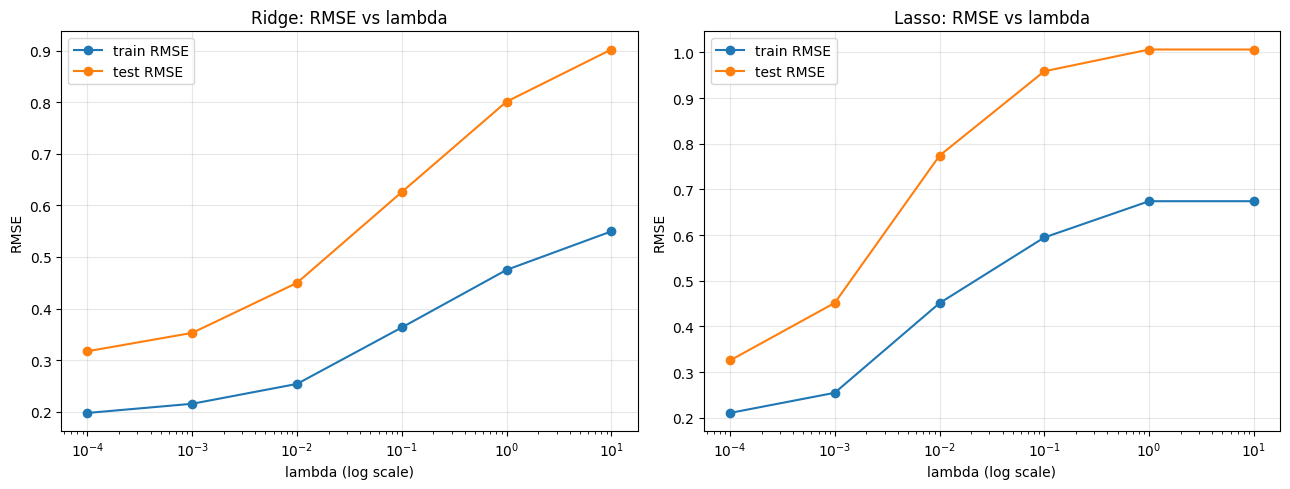

Best lambda for Ridge (min test RMSE): 0.0001, test RMSE=0.3173
Best lambda for Lasso (min test RMSE): 0.0001, test RMSE=0.3254


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(lambdas, ridge_train_rmse, 'o-', label='train RMSE')
axes[0].plot(lambdas, ridge_test_rmse, 'o-', label='test RMSE')
axes[0].set_xscale('log')
axes[0].set_xlabel('lambda (log scale)')
axes[0].set_ylabel('RMSE')
axes[0].set_title('Ridge: RMSE vs lambda')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(lambdas, lasso_train_rmse, 'o-', label='train RMSE')
axes[1].plot(lambdas, lasso_test_rmse, 'o-', label='test RMSE')
axes[1].set_xscale('log')
axes[1].set_xlabel('lambda (log scale)')
axes[1].set_ylabel('RMSE')
axes[1].set_title('Lasso: RMSE vs lambda')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

best_ridge_lambda = lambdas[np.argmin(ridge_test_rmse)]
best_lasso_lambda = lambdas[np.argmin(lasso_test_rmse)]
print(f"Best lambda for Ridge (min test RMSE): {best_ridge_lambda}, test RMSE={min(ridge_test_rmse):.4f}")
print(f"Best lambda for Lasso (min test RMSE): {best_lasso_lambda}, test RMSE={min(lasso_test_rmse):.4f}")

**Discussion:** I fit Ridge and Lasso for p=15 across λ ∈ {0.0001, ..., 10}. Unlike the classic U-shaped curve, both models showed test RMSE increasing monotonically as λ increased, with the smallest λ (0.0001) giving the lowest test RMSE for both (Ridge: 0.317, Lasso: 0.325) — nearly matching the unregularized p=15 result from part (a) (0.312). This suggests that the overfitting in part (a) was mild enough that little to no regularization was actually needed, and the true optimum likely lies at or below the smallest λ tested. Comparing the two models directly, Ridge outperformed Lasso at every λ value, and degraded more gracefully as λ increased — Lasso's test RMSE rose much faster (e.g., at λ=0.01, Lasso's test RMSE of 0.774 is far worse than Ridge's 0.450), consistent with Lasso's L1 penalty aggressively zeroing out coefficients rather than just shrinking them, which removes polynomial terms the model still needed. By λ=1, Lasso's train and test RMSE become identical to λ=10, indicating it had already zeroed out nearly all coefficients by that point.

## (c) Coefficient Sparsity: Lasso vs Ridge

Bar chart of |θ_j| for best Lasso vs best Ridge. Count near-zero Lasso coefficients (threshold 1e-3).

In [11]:
best_ridge = Ridge(alpha=best_ridge_lambda)
best_ridge.fit(X_train_poly, y_train)

best_lasso = Lasso(alpha=best_lasso_lambda, max_iter=100000)
best_lasso.fit(X_train_poly, y_train)

ridge_coefs = best_ridge.coef_
lasso_coefs = best_lasso.coef_

print("Ridge coefficients:", ridge_coefs)
print("Lasso coefficients:", lasso_coefs)


Ridge coefficients: [  4.42972432  -0.78976969 -22.51924497   9.19321229  22.86314314
 -17.09620097   2.49242827   0.85356203  -4.85262744  12.79243689
  -3.65024303   6.84559656  -0.71300512 -11.64418491   1.5916894 ]
Lasso coefficients: [  4.1405796    0.48009008 -20.43481116  -0.          19.98012183
  -0.           0.           0.          -0.           0.41867723
  -3.99367356   0.          -0.          -0.57563583  -0.        ]


In [12]:
threshold = 1e-3

ridge_num_zero = np.sum(np.abs(ridge_coefs) < threshold)
lasso_num_zero = np.sum(np.abs(lasso_coefs) < threshold)

print(f"Ridge: {ridge_num_zero} / {len(ridge_coefs)} coefficients are ~zero (threshold={threshold})")
print(f"Lasso: {lasso_num_zero} / {len(lasso_coefs)} coefficients are ~zero (threshold={threshold})")

Ridge: 0 / 15 coefficients are ~zero (threshold=0.001)
Lasso: 8 / 15 coefficients are ~zero (threshold=0.001)


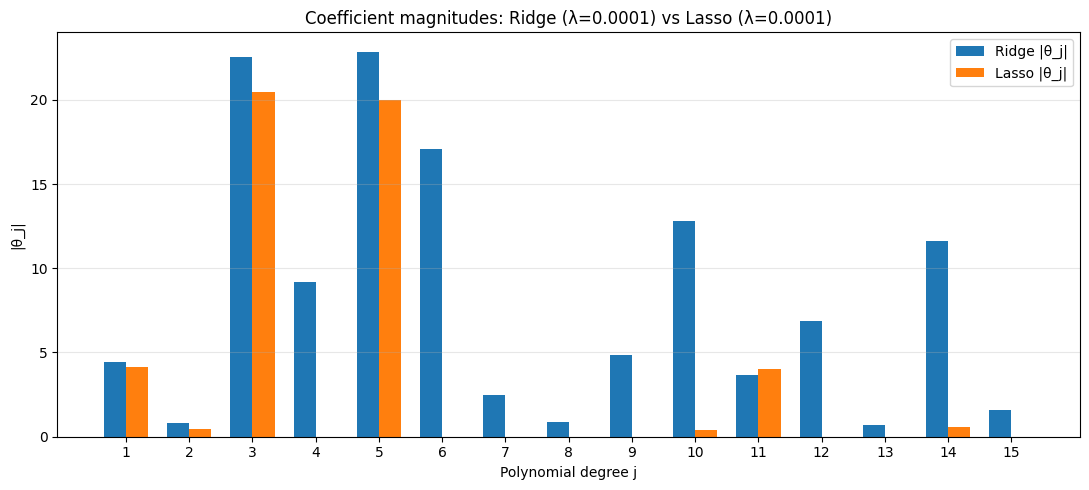

In [13]:
degrees_j = np.arange(1, p + 1)  # x^1 through x^15

fig, ax = plt.subplots(figsize=(11, 5))
width = 0.35

ax.bar(degrees_j - width/2, np.abs(ridge_coefs), width, label='Ridge |θ_j|')
ax.bar(degrees_j + width/2, np.abs(lasso_coefs), width, label='Lasso |θ_j|')

ax.set_xlabel('Polynomial degree j')
ax.set_ylabel('|θ_j|')
ax.set_title(f'Coefficient magnitudes: Ridge (λ={best_ridge_lambda}) vs Lasso (λ={best_lasso_lambda})')
ax.set_xticks(degrees_j)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

**Discussion:** Using each model's best λ from part (b) (both 0.0001 in this case), I compared the fitted coefficient magnitudes. Ridge did not zero out any of its 15 coefficients — every polynomial term retained some non-negligible weight, consistent with the L2 penalty only shrinking coefficients smoothly rather than eliminating them. Lasso, in contrast, drove 8 of 15 coefficients below the 1e-3 threshold, effectively removing over half the polynomial terms from the model. This is visible directly in the bar chart: at degrees like 7, 9, 12, 13, and 15, Ridge retains a clear non-zero bar while Lasso's is flush with zero, whereas both models keep substantial weight on lower odd-degree terms (1, 3, 5) that likely matter most for approximating the underlying sine function. This confirms the theoretical difference discussed in B2(b): the L1 penalty's constant-magnitude gradient near zero pushes small coefficients all the way to exactly zero, producing sparse solutions, while the L2 penalty's gradient vanishes as θⱼ→0, so Ridge coefficients shrink but rarely reach zero exactly.